# N04 — Concept-Layer Reliability

**Question.** Can concept-layer uncertainty identify mapped-KL grading errors better than maximum-softmax response (MSR)?

The primary comparison uses the same frozen ensemble table:

- **All-concept entropy:** mean normalized entropy across osteophyte, sclerosis, and JSN.
- **MSR:** `1 − max(mapped-KL probability)`.

N04 performs no image inference, training, checkpoint selection, or recalibration.

## Reader Guide

**Pipeline role:** Tests whether concept-layer uncertainty identifies mapped-KL errors better than maximum-softmax response.

**Inputs:** the same frozen N02B prediction table used for transfer analysis. **Produces:** reliability scores, risk-coverage curves, bootstrap intervals, threshold-transfer evidence, and a scientific verdict.

**Boundary:** no image inference, retraining, checkpoint selection, or recalibration occurs here.

## Endpoints

The primary comparison uses the same frozen three-seed ensemble prediction table for both scores:

- **MSR:** one minus the maximum mapped-KL probability.
- **All-concept entropy:** the mean normalized entropy of osteophyte, sclerosis, and JSN predictions.

Entropy is divided by the maximum possible entropy, `log(K)`. Therefore, every entropy value lies between 0 and 1 and can be compared across four-class concept heads and the five-class KL head.

The OAI-validation threshold is fixed at **80% target coverage** and transferred unchanged to OAI test and NHANES confirmation.


In [1]:



from dataclasses import dataclass

from datetime import datetime, timezone

from pathlib import Path

from typing import Any

import hashlib

import json

import sys

import warnings



IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:

    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from sklearn.metrics import average_precision_score, roc_auc_score

from tqdm.auto import tqdm



@dataclass(frozen=True)

class Config:

    bootstrap_repetitions: int = 2000

    bootstrap_seed: int = 20260805

    target_coverage: float = 0.80

    practical_aurc_margin: float = 0.01

    practical_auroc_margin: float = 0.02



CONFIG = Config()



FINAL_ROOT = Path("/content/drive/MyDrive/MasterThesis/Final Pipeline")

if not FINAL_ROOT.exists():

    raise FileNotFoundError(f"Final Pipeline root not found: {FINAL_ROOT}")



N03_RESULT_DIR = FINAL_ROOT / "results" / "N03"

N02B_PREDICTION_DIR = FINAL_ROOT / "predictions" / "N02B"



RESULT_DIR = FINAL_ROOT / "results" / "N04"

TABLE_DIR = FINAL_ROOT / "tables" / "N04"

FIGURE_DIR = FINAL_ROOT / "figures" / "N04"

PREDICTION_DIR = FINAL_ROOT / "predictions" / "N04"

MANIFEST_DIR = FINAL_ROOT / "manifests" / "N04"



for folder in (RESULT_DIR, TABLE_DIR, FIGURE_DIR, PREDICTION_DIR, MANIFEST_DIR):

    folder.mkdir(parents=True, exist_ok=True)

    for path in folder.iterdir():

        if path.is_file():

            path.unlink()



PROTOCOL = "N04_CONCEPT_RELIABILITY"

NOTEBOOK_NAME = "N04_Concept_Layer_Reliability.ipynb"

RUN_STARTED_TIMESTAMP = datetime.now(timezone.utc).timestamp()



print("Final Pipeline:", FINAL_ROOT)

print("Protocol:", PROTOCOL)


Mounted at /content/drive
Final Pipeline: /content/drive/MyDrive/MasterThesis/Final Pipeline
Protocol: N04_CONCEPT_RELIABILITY


In [2]:



def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for block in iter(lambda: handle.read(chunk_size), b""):

            digest.update(block)

    return digest.hexdigest()



def atomic_csv(frame: pd.DataFrame, path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    frame.to_csv(temporary, index=False)

    temporary.replace(path)



def atomic_json(payload: dict[str, Any], path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    temporary.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    temporary.replace(path)



def normalize_rows(values: np.ndarray) -> np.ndarray:

    values = np.asarray(values, dtype=np.float64)

    if values.ndim != 2 or not np.isfinite(values).all():

        raise ValueError("Invalid probability matrix.")

    if values.min() < -1e-8:

        raise ValueError("Negative probability found.")

    values = np.clip(values, 0.0, None)

    sums = values.sum(axis=1, keepdims=True)

    if (sums <= 0).any():

        raise ValueError("Zero-mass probability row.")

    return values / sums



def probability_block(frame: pd.DataFrame, prefix: str, classes: int) -> np.ndarray:

    columns = [f"{prefix}_prob_{grade}" for grade in range(classes)]

    missing = [column for column in columns if column not in frame.columns]

    if missing:

        raise KeyError(f"Missing {prefix} columns: {missing}")

    values = frame[columns].to_numpy(dtype=np.float64)

    if values.shape != (len(frame), classes):

        raise RuntimeError(f"Invalid {prefix} shape: {values.shape}")

    return normalize_rows(values)



def normalized_entropy(probabilities: np.ndarray) -> np.ndarray:

    probabilities = normalize_rows(probabilities)

    values = np.clip(probabilities, 1e-12, 1.0)

    return -np.sum(values * np.log(values), axis=1) / np.log(probabilities.shape[1])



def safe_auroc(errors: np.ndarray, scores: np.ndarray) -> float:

    return np.nan if np.unique(errors).size < 2 else float(roc_auc_score(errors, scores))



def safe_auprc(errors: np.ndarray, scores: np.ndarray) -> float:

    return np.nan if np.sum(errors) == 0 else float(average_precision_score(errors, scores))



def grouped_risk_coverage(errors: np.ndarray, scores: np.ndarray) -> pd.DataFrame:

    errors = np.asarray(errors, dtype=np.float64)

    scores = np.asarray(scores, dtype=np.float64)

    if len(errors) != len(scores) or not np.isfinite(errors).all() or not np.isfinite(scores).all():

        raise ValueError("Invalid errors or scores.")

    order = np.argsort(scores, kind="mergesort")

    sorted_scores, sorted_errors = scores[order], errors[order]

    unique_scores, counts = np.unique(sorted_scores, return_counts=True)

    rows = [{"threshold": -np.inf, "coverage": 0.0, "risk": 0.0, "retained": 0}]

    start = retained = 0

    cumulative_errors = 0.0

    for score, count in zip(unique_scores, counts):

        stop = start + int(count)

        retained += int(count)

        cumulative_errors += float(sorted_errors[start:stop].sum())

        rows.append({

            "threshold": float(score),

            "coverage": float(retained / len(errors)),

            "risk": float(cumulative_errors / retained),

            "retained": retained,

        })

        start = stop

    return pd.DataFrame(rows)



def grouped_aurc(errors: np.ndarray, scores: np.ndarray) -> float:

    curve = grouped_risk_coverage(errors, scores)

    return float(np.trapezoid(curve["risk"].to_numpy(), curve["coverage"].to_numpy()))



def score_metrics(errors: np.ndarray, scores: np.ndarray) -> dict[str, float]:

    return {

        "error_rate": float(np.mean(errors)),

        "error_auroc": safe_auroc(errors, scores),

        "error_auprc": safe_auprc(errors, scores),

        "aurc": grouped_aurc(errors, scores),

    }



def save_figure(figure, name: str) -> None:

    figure.savefig(FIGURE_DIR / f"{name}.png", dpi=300, bbox_inches="tight")

    figure.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")

    plt.show()

    plt.close(figure)


## 1. Input gate and ensemble-parity audit

N04 uses only the frozen N02B prediction tables. It performs no image inference, no model training, and no recalibration.

The parity audit verifies that MSR and concept entropy use:

- the same knees;
- the same row order;
- the same ensemble-averaged prediction table;
- probability-derived predictions that match the saved mapped-KL predictions.


In [3]:



N03_STATUS_PATH = (

    N03_RESULT_DIR

    / "status.json"

)



OAI_PREDICTION_PATH = (

    N02B_PREDICTION_DIR

    / "oai_predictions.csv"

)



NHANES_PREDICTION_PATH = (

    N02B_PREDICTION_DIR

    / "nhanes_predictions.csv"

)



required_inputs = [

    N03_STATUS_PATH,

    OAI_PREDICTION_PATH,

    NHANES_PREDICTION_PATH,

]



missing_inputs = [

    path

    for path in required_inputs

    if (

        not path.exists()

        or path.stat().st_size == 0

    )

]



if missing_inputs:

    raise FileNotFoundError(

        "Missing N04 inputs:\n"

        + "\n".join(

            f" - {path}"

            for path in missing_inputs

        )

    )



N03_STATUS = json.loads(

    N03_STATUS_PATH.read_text(

        encoding="utf-8"

    )

)



if not N03_STATUS.get(

    "passed",

    False,

):

    raise RuntimeError(

        "N03 did not pass."

    )



OAI_PREDICTIONS = pd.read_csv(

    OAI_PREDICTION_PATH,

    low_memory=False,

)



NHANES_PREDICTIONS = pd.read_csv(

    NHANES_PREDICTION_PATH,

    low_memory=False,

)



base_columns = {

    "knee_key",

    "patient_id",

    "kl_grade",

    "mapped_kl_prediction",

}



probability_specifications = {

    "mapped_kl": 5,

    "osteophyte_max": 4,

    "sclerosis_max": 4,

    "jsn_max": 4,

}



required_probability_columns = {

    f"{prefix}_prob_{grade}"

    for prefix, classes in probability_specifications.items()

    for grade in range(classes)

}



for name, frame in (

    ("OAI", OAI_PREDICTIONS),

    ("NHANES", NHANES_PREDICTIONS),

):

    missing_base = (

        base_columns

        - set(frame.columns)

    )



    missing_probabilities = (

        required_probability_columns

        - set(frame.columns)

    )



    if missing_base:

        raise KeyError(

            f"{name} predictions are missing base columns: "

            f"{sorted(missing_base)}"

        )



    if missing_probabilities:

        raise KeyError(

            f"{name} predictions are missing probability columns: "

            f"{sorted(missing_probabilities)}"

        )



    if not frame[

        "knee_key"

    ].is_unique:

        raise RuntimeError(

            f"{name} knee_key is not unique."

        )



if "model_split" not in OAI_PREDICTIONS.columns:

    raise KeyError(

        "OAI predictions do not contain model_split."

    )



if "analysis_subset" not in NHANES_PREDICTIONS.columns:

    raise KeyError(

        "NHANES predictions do not contain analysis_subset."

    )



OAI_VALIDATION = (

    OAI_PREDICTIONS.loc[

        OAI_PREDICTIONS[

            "model_split"

        ]

        .astype(str)

        .str.strip()

        .str.lower()

        .eq("validation")

    ]

    .copy()

    .reset_index(drop=True)

)



OAI_TEST = (

    OAI_PREDICTIONS.loc[

        OAI_PREDICTIONS[

            "model_split"

        ]

        .astype(str)

        .str.strip()

        .str.lower()

        .eq("test")

    ]

    .copy()

    .reset_index(drop=True)

)



NHANES_CONFIRMATION = (

    NHANES_PREDICTIONS.loc[

        NHANES_PREDICTIONS[

            "analysis_subset"

        ]

        .astype(str)

        .str.strip()

        .str.lower()

        .eq("confirmation")

    ]

    .copy()

    .reset_index(drop=True)

)



for name, frame in (

    ("OAI validation", OAI_VALIDATION),

    ("OAI test", OAI_TEST),

    (

        "NHANES confirmation",

        NHANES_CONFIRMATION,

    ),

):

    if len(frame) == 0:

        raise RuntimeError(

            f"{name} is empty."

        )



parity_rows = []



for dataset_name, frame in (

    ("OAI validation", OAI_VALIDATION),

    ("OAI test", OAI_TEST),

    (

        "NHANES confirmation",

        NHANES_CONFIRMATION,

    ),

):

    mapped_probabilities = probability_block(

        frame,

        "mapped_kl",

        5,

    )



    derived_predictions = (

        mapped_probabilities.argmax(

            axis=1

        )

    )



    saved_predictions = frame[

        "mapped_kl_prediction"

    ].to_numpy(

        dtype=int

    )



    row_order_unique = bool(

        frame["knee_key"].is_unique

    )



    probability_predictions_match = bool(

        np.array_equal(

            derived_predictions,

            saved_predictions,

        )

    )



    parity_rows.append({

        "dataset": dataset_name,

        "knees": int(len(frame)),

        "unique_knee_order": row_order_unique,

        "probability_predictions_match":

            probability_predictions_match,

        "same_table_for_all_scores": True,

        "max_probability_row_sum_deviation":

            float(

                np.max(

                    np.abs(

                        mapped_probabilities.sum(

                            axis=1

                        )

                        - 1.0

                    )

                )

            ),

    })



ensemble_parity = pd.DataFrame(

    parity_rows

)



if not ensemble_parity[

    [

        "unique_knee_order",

        "probability_predictions_match",

        "same_table_for_all_scores",

    ]

].all().all():

    display(

        ensemble_parity

    )



    raise RuntimeError(

        "Ensemble parity audit failed."

    )



atomic_csv(

    ensemble_parity,

    TABLE_DIR

    / "T00_ensemble_parity.csv",

)



atomic_json(

    {

        "status": "PASS",

        "same_prediction_tables": True,

        "same_row_order": True,

        "probability_predictions_match": True,

        "datasets": parity_rows,

        "created_utc": datetime.now(

            timezone.utc

        ).isoformat(),

    },

    RESULT_DIR

    / "ensemble_parity_audit.json",

)



atomic_csv(

    pd.DataFrame([

        {

            "path": str(path),

            "size_bytes": int(

                path.stat().st_size

            ),

            "sha256": sha256_file(path),

        }

        for path in required_inputs

    ]),

    MANIFEST_DIR

    / "input_manifest.csv",

)



print(

    "OAI validation knees:",

    len(OAI_VALIDATION),

)



print(

    "OAI test knees:",

    len(OAI_TEST),

)



print(

    "NHANES confirmation knees:",

    len(NHANES_CONFIRMATION),

)



print(

    "Required probability columns:",

    len(required_probability_columns),

)



print(

    "Ensemble parity audit: PASS"

)



print(

    "Input gate: PASS"

)


OAI validation knees: 1052
OAI test knees: 1050
NHANES confirmation knees: 2392
Required probability columns: 17
Ensemble parity audit: PASS
Input gate: PASS


## 2. Reliability scores

In [4]:



def build_reliability_frame(frame: pd.DataFrame, cohort: str, subset: str) -> pd.DataFrame:

    mapped = probability_block(frame, "mapped_kl", 5)

    osteophyte = probability_block(frame, "osteophyte_max", 4)

    sclerosis = probability_block(frame, "sclerosis_max", 4)

    jsn = probability_block(frame, "jsn_max", 4)



    truth = frame["kl_grade"].to_numpy(dtype=int)

    prediction = mapped.argmax(axis=1)



    output = frame[["knee_key", "patient_id", "kl_grade"]].copy()

    output["cohort"] = cohort

    output["subset"] = subset

    output["mapped_kl_prediction"] = prediction

    output["error"] = (prediction != truth).astype(int)

    output["msr"] = 1.0 - mapped.max(axis=1)

    output["kl_entropy"] = normalized_entropy(mapped)

    output["shared_concept_entropy"] = np.mean(

        np.column_stack([normalized_entropy(osteophyte), normalized_entropy(sclerosis)]),

        axis=1,

    )

    output["all_concept_entropy"] = np.mean(

        np.column_stack([

            normalized_entropy(osteophyte),

            normalized_entropy(sclerosis),

            normalized_entropy(jsn),

        ]),

        axis=1,

    )

    return output



OAI_VALIDATION_RELIABILITY = build_reliability_frame(OAI_VALIDATION, "OAI", "validation")

OAI_TEST_RELIABILITY = build_reliability_frame(OAI_TEST, "OAI", "test")

NHANES_RELIABILITY = build_reliability_frame(NHANES_CONFIRMATION, "NHANES III", "confirmation")



RELIABILITY_DATA = pd.concat(

    [OAI_VALIDATION_RELIABILITY, OAI_TEST_RELIABILITY, NHANES_RELIABILITY],

    ignore_index=True,

)



SCORE_COLUMNS = {

    "MSR": "msr",

    "KL entropy": "kl_entropy",

    "Shared concept entropy": "shared_concept_entropy",

    "All concept entropy": "all_concept_entropy",

}



PRIMARY_BASELINE = "MSR"

PRIMARY_CONCEPT_SCORE = "All concept entropy"



atomic_csv(RELIABILITY_DATA, PREDICTION_DIR / "reliability_scores.csv")

print("Primary comparison:", PRIMARY_CONCEPT_SCORE, "vs", PRIMARY_BASELINE)

print("Score construction: PASS")


Primary comparison: All concept entropy vs MSR
Score construction: PASS


## 3. Failure ranking and risk–coverage

In [5]:



evaluation_sets = {

    "OAI validation": OAI_VALIDATION_RELIABILITY,

    "OAI test": OAI_TEST_RELIABILITY,

    "NHANES confirmation": NHANES_RELIABILITY,

}



metric_rows, curve_rows = [], []



for dataset_name, frame in evaluation_sets.items():

    errors = frame["error"].to_numpy(dtype=int)

    for score_name, column in SCORE_COLUMNS.items():

        scores = frame[column].to_numpy(dtype=float)

        metric_rows.append({

            "dataset": dataset_name,

            "score": score_name,

            "n": int(len(frame)),

            **score_metrics(errors, scores),

        })

        curve = grouped_risk_coverage(errors, scores)

        curve.insert(0, "score", score_name)

        curve.insert(0, "dataset", dataset_name)

        curve_rows.append(curve)



reliability_metrics = pd.DataFrame(metric_rows)

risk_coverage_curves = pd.concat(curve_rows, ignore_index=True)



atomic_csv(reliability_metrics, TABLE_DIR / "T01_reliability_metrics.csv")

atomic_csv(risk_coverage_curves, TABLE_DIR / "T02_risk_coverage_curves.csv")

display(reliability_metrics.round(4))


,dataset,score,n,error_rate,error_auroc,error_auprc,aurc
0,OAI validation,MSR,1052,0.3327,0.7321,0.5351,0.1779
1,OAI validation,KL entropy,1052,0.3327,0.7384,0.5510,0.1760
2,OAI validation,Shared concept entropy,1052,0.3327,0.3935,0.2743,0.3806
3,OAI validation,All concept entropy,1052,0.3327,0.4472,0.2893,0.3412
4,OAI test,MSR,1050,0.3743,0.7458,0.5999,0.2067
5,OAI test,KL entropy,1050,0.3743,0.7482,0.6110,0.2063
6,OAI test,Shared concept entropy,1050,0.3743,0.3723,0.2974,0.4366
7,OAI test,All concept entropy,1050,0.3743,0.4403,0.3228,0.3831
8,NHANES confirmation,MSR,2392,0.5548,0.5356,0.6065,0.5562
9,NHANES confirmation,KL entropy,2392,0.5548,0.5516,0.6325,0.5488


## 4. Paired participant bootstrap

In [6]:



def patient_groups(frame: pd.DataFrame) -> list[np.ndarray]:

    patients = frame["patient_id"].astype(str).to_numpy()

    return [np.flatnonzero(patients == patient) for patient in np.unique(patients)]



def sample_patient_indices(groups: list[np.ndarray], rng: np.random.Generator) -> np.ndarray:

    selected = rng.integers(0, len(groups), size=len(groups))

    return np.concatenate([groups[index] for index in selected])



def paired_bootstrap(frame: pd.DataFrame, dataset_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:

    groups = patient_groups(frame)

    rng = np.random.default_rng(CONFIG.bootstrap_seed)

    errors = frame["error"].to_numpy(dtype=int)

    msr = frame[SCORE_COLUMNS[PRIMARY_BASELINE]].to_numpy(dtype=float)

    concept = frame[SCORE_COLUMNS[PRIMARY_CONCEPT_SCORE]].to_numpy(dtype=float)

    rows = []



    for repetition in tqdm(range(CONFIG.bootstrap_repetitions), desc=f"Bootstrap: {dataset_name}"):

        indices = sample_patient_indices(groups, rng)

        sampled_errors = errors[indices]

        baseline = score_metrics(sampled_errors, msr[indices])

        candidate = score_metrics(sampled_errors, concept[indices])

        rows.append({

            "dataset": dataset_name,

            "repetition": repetition,

            "msr_aurc": baseline["aurc"],

            "concept_aurc": candidate["aurc"],

            "difference_concept_minus_msr_aurc": candidate["aurc"] - baseline["aurc"],

            "msr_auroc": baseline["error_auroc"],

            "concept_auroc": candidate["error_auroc"],

            "difference_concept_minus_msr_auroc": candidate["error_auroc"] - baseline["error_auroc"],

            "msr_auprc": baseline["error_auprc"],

            "concept_auprc": candidate["error_auprc"],

            "difference_concept_minus_msr_auprc": candidate["error_auprc"] - baseline["error_auprc"],

        })



    draws = pd.DataFrame(rows)

    interval_rows = []

    for metric, column in (

        ("aurc", "difference_concept_minus_msr_aurc"),

        ("error_auroc", "difference_concept_minus_msr_auroc"),

        ("error_auprc", "difference_concept_minus_msr_auprc"),

    ):

        values = draws[column].to_numpy(dtype=float)

        valid = values[np.isfinite(values)]

        if len(valid) == 0:

            raise RuntimeError(f"No valid bootstrap draws for {dataset_name}, {metric}.")

        interval_rows.append({

            "dataset": dataset_name,

            "metric": metric,

            "difference_concept_minus_msr": float(np.mean(valid)),

            "ci_lower": float(np.quantile(valid, 0.025)),

            "ci_upper": float(np.quantile(valid, 0.975)),

            "valid_draws": int(len(valid)),

        })

    return draws, pd.DataFrame(interval_rows)



oai_draws, oai_intervals = paired_bootstrap(OAI_TEST_RELIABILITY, "OAI test")

nhanes_draws, nhanes_intervals = paired_bootstrap(NHANES_RELIABILITY, "NHANES confirmation")



bootstrap_draws = pd.concat([oai_draws, nhanes_draws], ignore_index=True)

bootstrap_intervals = pd.concat([oai_intervals, nhanes_intervals], ignore_index=True)



atomic_csv(bootstrap_draws, TABLE_DIR / "T03_bootstrap_draws.csv")

atomic_csv(bootstrap_intervals, TABLE_DIR / "T04_bootstrap_intervals.csv")

display(bootstrap_intervals.round(4))


Bootstrap: OAI test:   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrap: NHANES confirmation:   0%|          | 0/2000 [00:00<?, ?it/s]

,dataset,metric,difference_concept_minus_msr,ci_lower,ci_upper,valid_draws
0,OAI test,aurc,0.1763,0.1437,0.2114,2000
1,OAI test,error_auroc,-0.3059,-0.3537,-0.2571,2000
2,OAI test,error_auprc,-0.2766,-0.3261,-0.2289,2000
3,NHANES confirmation,aurc,-0.1673,-0.1943,-0.1393,2000
4,NHANES confirmation,error_auroc,0.1687,0.1310,0.2052,2000
5,NHANES confirmation,error_auprc,0.1160,0.0826,0.1493,2000


## 5. OAI threshold transfer at 80% coverage

Each uncertainty threshold is selected once on OAI validation to retain approximately 80% of knees.

The same numeric threshold is then applied without adjustment to OAI test and NHANES confirmation.


In [7]:



def select_threshold(

    scores: np.ndarray,

    target_coverage: float,

) -> float:

    scores = np.asarray(

        scores,

        dtype=float,

    )



    if not (

        0.0

        < target_coverage

        <= 1.0

    ):

        raise ValueError(

            "Target coverage must be in (0, 1]."

        )



    if not np.isfinite(

        scores

    ).all():

        raise ValueError(

            "Threshold scores contain non-finite values."

        )



    return float(

        np.quantile(

            scores,

            target_coverage,

            method="higher",

        )

    )





def threshold_result(

    frame: pd.DataFrame,

    score_column: str,

    threshold: float,

) -> dict[str, float]:

    scores = frame[

        score_column

    ].to_numpy(

        dtype=float

    )



    errors = frame[

        "error"

    ].to_numpy(

        dtype=float

    )



    retained = (

        scores <= threshold

    )



    return {

        "coverage": float(

            retained.mean()

        ),

        "risk": (

            float(

                errors[

                    retained

                ].mean()

            )

            if retained.any()

            else np.nan

        ),

        "retained": int(

            retained.sum()

        ),

        "n": int(

            len(frame)

        ),

    }





threshold_rows = []

selected_threshold_rows = []



for score_name, score_column in (

    SCORE_COLUMNS.items()

):

    threshold = select_threshold(

        OAI_VALIDATION_RELIABILITY[

            score_column

        ].to_numpy(

            dtype=float

        ),

        CONFIG.target_coverage,

    )



    validation_result = threshold_result(

        OAI_VALIDATION_RELIABILITY,

        score_column,

        threshold,

    )



    selected_threshold_rows.append({

        "score": score_name,

        "score_column": score_column,

        "threshold": float(

            threshold

        ),

        "target_coverage": float(

            CONFIG.target_coverage

        ),

        "achieved_oai_validation_coverage":

            float(

                validation_result[

                    "coverage"

                ]

            ),

        "achieved_oai_validation_risk":

            float(

                validation_result[

                    "risk"

                ]

            ),

        "selected_utc": datetime.now(

            timezone.utc

        ).isoformat(),

    })



    for dataset_name, frame in (

        evaluation_sets.items()

    ):

        result = threshold_result(

            frame,

            score_column,

            threshold,

        )



        threshold_rows.append({

            "score": score_name,

            "threshold_source":

                "OAI validation",

            "target_coverage":

                CONFIG.target_coverage,

            "threshold":

                threshold,

            "evaluation_dataset":

                dataset_name,

            **result,

            "coverage_error":

                result["coverage"]

                - CONFIG.target_coverage,

        })



threshold_transfer = pd.DataFrame(

    threshold_rows

)



selected_thresholds = pd.DataFrame(

    selected_threshold_rows

)



atomic_csv(

    threshold_transfer,

    TABLE_DIR

    / "T05_threshold_transfer.csv",

)



atomic_csv(

    selected_thresholds,

    TABLE_DIR

    / "T05B_selected_thresholds.csv",

)



atomic_json(

    {

        "threshold_source":

            "OAI validation",

        "target_coverage":

            float(

                CONFIG.target_coverage

            ),

        "scores":

            selected_threshold_rows,

    },

    RESULT_DIR

    / "selected_thresholds.json",

)



display(

    selected_thresholds.round(4)

)



display(

    threshold_transfer.round(4)

)


,score,score_column,threshold,target_coverage,achieved_oai_validation_coverage,achieved_oai_validation_risk,selected_utc
0,MSR,msr,0.5217,0.8,0.8004,0.2720,2026-08-05T17:16:16.091118+00:00
1,KL entropy,kl_entropy,0.7154,0.8,0.8004,0.2672,2026-08-05T17:16:16.091827+00:00
2,Shared concept entropy,shared_concept_entropy,0.6871,0.8,0.8004,0.3634,2026-08-05T17:16:16.092200+00:00
3,All concept entropy,all_concept_entropy,0.6521,0.8,0.8004,0.3610,2026-08-05T17:16:16.092577+00:00


,score,threshold_source,target_coverage,threshold,evaluation_dataset,coverage,risk,retained,n,coverage_error
0,MSR,OAI validation,0.8,0.5217,OAI validation,0.8004,0.2720,842,1052,0.0004
1,MSR,OAI validation,0.8,0.5217,OAI test,0.7695,0.2908,808,1050,-0.0305
2,MSR,OAI validation,0.8,0.5217,NHANES confirmation,0.7320,0.5191,1751,2392,-0.0680
3,KL entropy,OAI validation,0.8,0.7154,OAI validation,0.8004,0.2672,842,1052,0.0004
4,KL entropy,OAI validation,0.8,0.7154,OAI test,0.7800,0.2967,819,1050,-0.0200
5,KL entropy,OAI validation,0.8,0.7154,NHANES confirmation,0.6681,0.5138,1598,2392,-0.1319
6,Shared concept entropy,OAI validation,0.8,0.6871,OAI validation,0.8004,0.3634,842,1052,0.0004
7,Shared concept entropy,OAI validation,0.8,0.6871,OAI test,0.8210,0.4118,862,1050,0.0210
8,Shared concept entropy,OAI validation,0.8,0.6871,NHANES confirmation,0.6091,0.4598,1457,2392,-0.1909
9,All concept entropy,OAI validation,0.8,0.6521,OAI validation,0.8004,0.3610,842,1052,0.0004


## 6. Scientific verdict

In [8]:



primary = bootstrap_intervals.loc[

    bootstrap_intervals["dataset"].eq("NHANES confirmation")

].set_index("metric")



aurc_estimate = float(primary.loc["aurc", "difference_concept_minus_msr"])

aurc_lower = float(primary.loc["aurc", "ci_lower"])

aurc_upper = float(primary.loc["aurc", "ci_upper"])



auroc_estimate = float(primary.loc["error_auroc", "difference_concept_minus_msr"])

auroc_lower = float(primary.loc["error_auroc", "ci_lower"])

auroc_upper = float(primary.loc["error_auroc", "ci_upper"])



aurc_better = aurc_upper < 0 and aurc_estimate < -CONFIG.practical_aurc_margin

auroc_better = auroc_lower > 0 and auroc_estimate > CONFIG.practical_auroc_margin

aurc_worse = aurc_lower > 0 and aurc_estimate > CONFIG.practical_aurc_margin

auroc_worse = auroc_upper < 0 and auroc_estimate < -CONFIG.practical_auroc_margin



if aurc_better and auroc_better:

    reliability_verdict = "concept_better_on_both_endpoints"

elif aurc_better:

    reliability_verdict = "concept_better_on_aurc_only"

elif auroc_better:

    reliability_verdict = "concept_better_on_auroc_only"

elif aurc_worse or auroc_worse:

    reliability_verdict = "concept_uncertainty_worse"

else:

    reliability_verdict = "no_clear_primary_advantage"



nhanes_table = reliability_metrics.loc[

    reliability_metrics["dataset"].eq("NHANES confirmation")

].set_index("score")



verdict = {

    "primary_baseline": PRIMARY_BASELINE,

    "primary_concept_score": PRIMARY_CONCEPT_SCORE,

    "reliability_verdict": reliability_verdict,

    "nhanes_msr_aurc": float(nhanes_table.loc[PRIMARY_BASELINE, "aurc"]),

    "nhanes_concept_aurc": float(nhanes_table.loc[PRIMARY_CONCEPT_SCORE, "aurc"]),

    "aurc_difference_concept_minus_msr": aurc_estimate,

    "aurc_difference_ci": [aurc_lower, aurc_upper],

    "nhanes_msr_error_auroc": float(nhanes_table.loc[PRIMARY_BASELINE, "error_auroc"]),

    "nhanes_concept_error_auroc": float(nhanes_table.loc[PRIMARY_CONCEPT_SCORE, "error_auroc"]),

    "auroc_difference_concept_minus_msr": auroc_estimate,

    "auroc_difference_ci": [auroc_lower, auroc_upper],

    "threshold_source": "OAI validation",

    "threshold_target_coverage": CONFIG.target_coverage,

    "thresholds_artifact": str(

        RESULT_DIR

        / "selected_thresholds.json"

    ),

    "ensemble_parity_status": "PASS",

}



atomic_json(verdict, RESULT_DIR / "scientific_verdict.json")

verdict_table = pd.DataFrame([{

    "verdict": reliability_verdict,

    "aurc_difference": aurc_estimate,

    "aurc_ci_lower": aurc_lower,

    "aurc_ci_upper": aurc_upper,

    "auroc_difference": auroc_estimate,

    "auroc_ci_lower": auroc_lower,

    "auroc_ci_upper": auroc_upper,

}])

atomic_csv(verdict_table, TABLE_DIR / "T06_verdict_summary.csv")

display(verdict_table.round(4))


,verdict,aurc_difference,aurc_ci_lower,aurc_ci_upper,auroc_difference,auroc_ci_lower,auroc_ci_upper
0,concept_better_on_both_endpoints,-0.1673,-0.1943,-0.1393,0.1687,0.131,0.2052


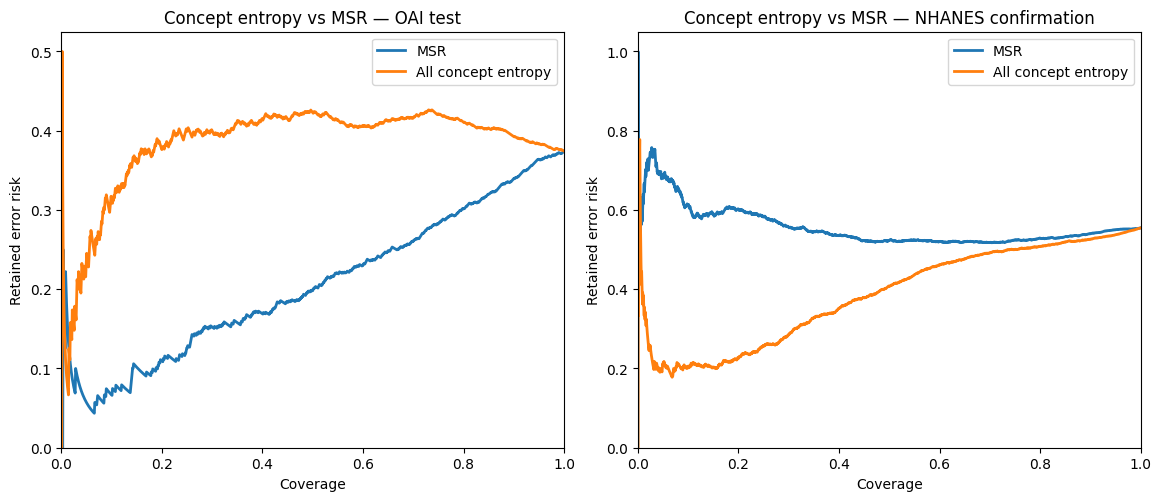

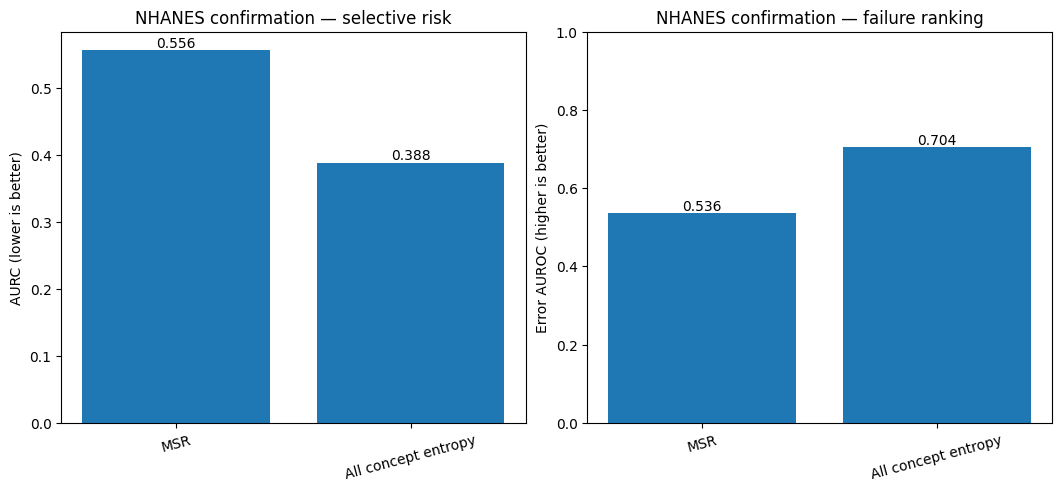

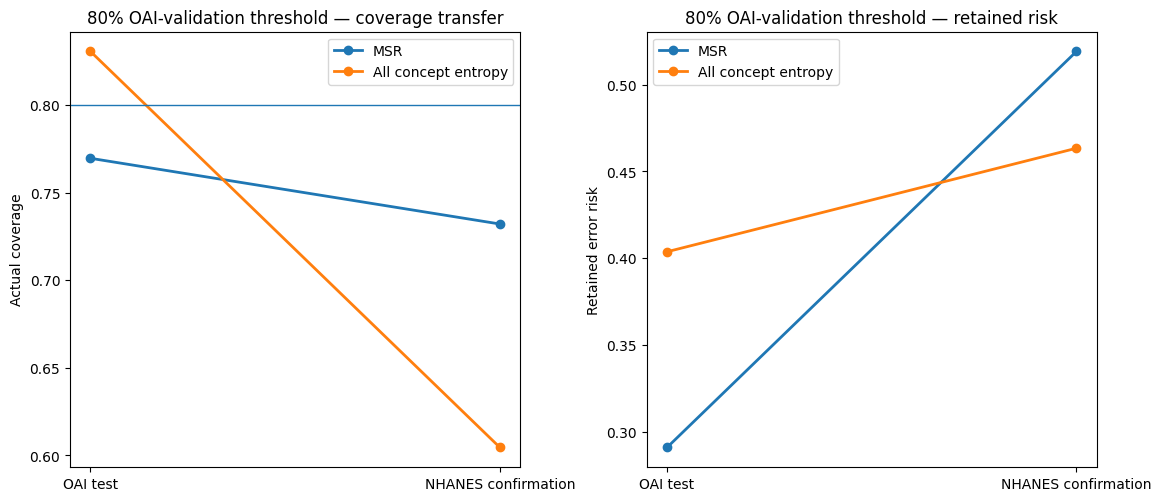

In [9]:



selected_scores = [

    PRIMARY_BASELINE,

    PRIMARY_CONCEPT_SCORE,

]



figure, axes = plt.subplots(

    1,

    2,

    figsize=(11.5, 4.9),

    constrained_layout=True,

)



for axis, dataset_name in zip(

    axes,

    [

        "OAI test",

        "NHANES confirmation",

    ],

):

    for score_name in selected_scores:

        curve = (

            risk_coverage_curves.loc[

                risk_coverage_curves[

                    "dataset"

                ].eq(dataset_name)

                & risk_coverage_curves[

                    "score"

                ].eq(score_name)

            ]

            .sort_values(

                "coverage"

            )

        )



        axis.plot(

            curve[

                "coverage"

            ],

            curve[

                "risk"

            ],

            linewidth=2,

            label=score_name,

        )



    axis.set_xlabel(

        "Coverage"

    )



    axis.set_ylabel(

        "Retained error risk"

    )



    axis.set_title(

        f"Concept entropy vs MSR — {dataset_name}"

    )



    axis.set_xlim(

        0.0,

        1.0,

    )



    axis.set_ylim(

        bottom=0.0

    )



    axis.legend()



save_figure(

    figure,

    "F01_risk_coverage",

)





nhanes_plot = (

    reliability_metrics.loc[

        reliability_metrics[

            "dataset"

        ].eq(

            "NHANES confirmation"

        )

        & reliability_metrics[

            "score"

        ].isin(

            selected_scores

        )

    ]

    .set_index(

        "score"

    )

    .loc[

        selected_scores

    ]

)



figure, axes = plt.subplots(

    1,

    2,

    figsize=(10.5, 4.8),

    constrained_layout=True,

)



bars_aurc = axes[0].bar(

    selected_scores,

    nhanes_plot[

        "aurc"

    ].to_numpy(

        dtype=float

    ),

)



axes[0].set_ylabel(

    "AURC (lower is better)"

)



axes[0].set_title(

    "NHANES confirmation — selective risk"

)



bars_auroc = axes[1].bar(

    selected_scores,

    nhanes_plot[

        "error_auroc"

    ].to_numpy(

        dtype=float

    ),

)



axes[1].set_ylabel(

    "Error AUROC (higher is better)"

)



axes[1].set_ylim(

    0.0,

    1.0,

)



axes[1].set_title(

    "NHANES confirmation — failure ranking"

)



for axis in axes:

    axis.tick_params(

        axis="x",

        rotation=15,

    )



for bars, axis in (

    (

        bars_aurc,

        axes[0],

    ),

    (

        bars_auroc,

        axes[1],

    ),

):

    for bar in bars:

        value = bar.get_height()



        axis.text(

            bar.get_x()

            + bar.get_width() / 2,

            value,

            f"{value:.3f}",

            ha="center",

            va="bottom",

        )



save_figure(

    figure,

    "F02_primary_metrics",

)





transfer = (

    threshold_transfer.loc[

        threshold_transfer[

            "score"

        ].isin(

            selected_scores

        )

        & threshold_transfer[

            "evaluation_dataset"

        ].isin([

            "OAI test",

            "NHANES confirmation",

        ])

    ]

    .copy()

)



figure, axes = plt.subplots(

    1,

    2,

    figsize=(11.5, 4.9),

    constrained_layout=True,

)



for score_name in selected_scores:

    rows = (

        transfer.loc[

            transfer[

                "score"

            ].eq(score_name)

        ]

        .set_index(

            "evaluation_dataset"

        )

        .loc[

            [

                "OAI test",

                "NHANES confirmation",

            ]

        ]

    )



    axes[0].plot(

        [

            "OAI test",

            "NHANES confirmation",

        ],

        rows[

            "coverage"

        ],

        marker="o",

        linewidth=2,

        label=score_name,

    )



    axes[1].plot(

        [

            "OAI test",

            "NHANES confirmation",

        ],

        rows[

            "risk"

        ],

        marker="o",

        linewidth=2,

        label=score_name,

    )



axes[0].axhline(

    CONFIG.target_coverage,

    linewidth=1,

)



axes[0].set_ylabel(

    "Actual coverage"

)



axes[0].set_title(

    "80% OAI-validation threshold — coverage transfer"

)



axes[1].set_ylabel(

    "Retained error risk"

)



axes[1].set_title(

    "80% OAI-validation threshold — retained risk"

)



for axis in axes:

    axis.legend()



save_figure(

    figure,

    "F03_threshold_transfer",

)


## 7. Final audit

In [10]:



required_files = [

    PREDICTION_DIR

    / "reliability_scores.csv",



    TABLE_DIR

    / "T00_ensemble_parity.csv",



    TABLE_DIR

    / "T01_reliability_metrics.csv",



    TABLE_DIR

    / "T02_risk_coverage_curves.csv",



    TABLE_DIR

    / "T03_bootstrap_draws.csv",



    TABLE_DIR

    / "T04_bootstrap_intervals.csv",



    TABLE_DIR

    / "T05_threshold_transfer.csv",



    TABLE_DIR

    / "T05B_selected_thresholds.csv",



    TABLE_DIR

    / "T06_verdict_summary.csv",



    RESULT_DIR

    / "ensemble_parity_audit.json",



    RESULT_DIR

    / "selected_thresholds.json",



    RESULT_DIR

    / "scientific_verdict.json",



    FIGURE_DIR

    / "F01_risk_coverage.png",



    FIGURE_DIR

    / "F01_risk_coverage.pdf",



    FIGURE_DIR

    / "F02_primary_metrics.png",



    FIGURE_DIR

    / "F02_primary_metrics.pdf",



    FIGURE_DIR

    / "F03_threshold_transfer.png",



    FIGURE_DIR

    / "F03_threshold_transfer.pdf",



    MANIFEST_DIR

    / "input_manifest.csv",

]



audit_rows = []



for path in required_files:

    exists = path.exists()



    nonempty = (

        exists

        and path.stat().st_size > 0

    )



    fresh = (

        nonempty

        and path.stat().st_mtime

        >= RUN_STARTED_TIMESTAMP - 1.0

    )



    audit_rows.append({

        "file": path.name,

        "path": str(path),

        "exists": exists,

        "nonempty": nonempty,

        "fresh": fresh,

        "size_bytes": (

            int(

                path.stat().st_size

            )

            if exists

            else None

        ),

        "sha256": (

            sha256_file(path)

            if nonempty

            else None

        ),

    })



drive_audit = pd.DataFrame(

    audit_rows

)



valid_bootstrap_draws = int(

    bootstrap_intervals[

        "valid_draws"

    ].min()

)



requested_bootstrap_draws = int(

    CONFIG.bootstrap_repetitions

)



criteria = {

    "N03 passed":

        bool(

            N03_STATUS.get(

                "passed",

                False,

            )

        ),



    "required probability columns are present":

        len(

            required_probability_columns

        ) == 17,



    "ensemble parity audit passed":

        bool(

            ensemble_parity[

                [

                    "unique_knee_order",

                    "probability_predictions_match",

                    "same_table_for_all_scores",

                ]

            ].all().all()

        ),



    "same prediction table used for all scores":

        len(

            RELIABILITY_DATA

        ) > 0,



    "OAI validation threshold source is nonempty":

        len(

            OAI_VALIDATION_RELIABILITY

        ) > 0,



    "OAI test is nonempty":

        len(

            OAI_TEST_RELIABILITY

        ) > 0,



    "NHANES confirmation is nonempty":

        len(

            NHANES_RELIABILITY

        ) > 0,



    "all four scores evaluated on all three datasets":

        len(

            reliability_metrics

        )

        == (

            len(SCORE_COLUMNS)

            * len(evaluation_sets)

        ),



    "paired participant bootstrap completed":

        len(

            bootstrap_draws

        )

        == (

            2

            * CONFIG.bootstrap_repetitions

        ),



    "at least 99 percent of bootstrap draws are valid":

        bool(

            (

                bootstrap_intervals[

                    "valid_draws"

                ]

                >= int(

                    0.99

                    * CONFIG.bootstrap_repetitions

                )

            ).all()

        ),



    "thresholds fitted on OAI validation only":

        bool(

            threshold_transfer[

                "threshold_source"

            ].eq(

                "OAI validation"

            ).all()

        ),



    "80 percent target coverage recorded":

        bool(

            np.isclose(

                selected_thresholds[

                    "target_coverage"

                ].to_numpy(

                    dtype=float

                ),

                CONFIG.target_coverage,

            ).all()

        ),



    "neutral reliability verdict produced":

        reliability_verdict in {

            "concept_better_on_both_endpoints",

            "concept_better_on_aurc_only",

            "concept_better_on_auroc_only",

            "concept_uncertainty_worse",

            "no_clear_primary_advantage",

        },



    "all required artifacts exist":

        bool(

            drive_audit[

                "nonempty"

            ].all()

        ),



    "all required artifacts are fresh":

        bool(

            drive_audit[

                "fresh"

            ].all()

        ),



    "all output paths use Final Pipeline":

        bool(

            drive_audit[

                "path"

            ].str.startswith(

                str(FINAL_ROOT)

            ).all()

        ),

}



criteria_table = pd.DataFrame([

    {

        "criterion": name,

        "passed": bool(

            value

        ),

    }

    for name, value in criteria.items()

])



passed = bool(

    criteria_table[

        "passed"

    ].all()

)



atomic_csv(

    drive_audit,

    RESULT_DIR

    / "drive_save_audit.csv",

)



atomic_csv(

    criteria_table,

    RESULT_DIR

    / "acceptance_criteria.csv",

)



execution_summary = {

    "stage": "N04",

    "protocol": PROTOCOL,

    "passed": passed,

    "reliability_verdict":

        reliability_verdict,

    "primary_baseline":

        PRIMARY_BASELINE,

    "primary_concept_score":

        PRIMARY_CONCEPT_SCORE,

    "target_coverage":

        float(

            CONFIG.target_coverage

        ),

    "valid_bootstrap_draws_minimum":

        valid_bootstrap_draws,

    "requested_bootstrap_draws":

        requested_bootstrap_draws,

    "ensemble_parity":

        "PASS",

    "created_utc": datetime.now(

        timezone.utc

    ).isoformat(),

}



atomic_json(

    execution_summary,

    RESULT_DIR

    / "execution_summary.json",

)



atomic_json(

    {

        "stage": "N04",

        "protocol": PROTOCOL,

        "passed": passed,

        "reliability_verdict":

            reliability_verdict,

        "primary_baseline":

            PRIMARY_BASELINE,

        "primary_concept_score":

            PRIMARY_CONCEPT_SCORE,

        "target_coverage":

            float(

                CONFIG.target_coverage

            ),

        "created_utc": datetime.now(

            timezone.utc

        ).isoformat(),

    },

    RESULT_DIR

    / "status.json",

)



manifest_rows = []



for path in (

    required_files

    + [

        RESULT_DIR

        / "execution_summary.json",

    ]

):

    if (

        path.exists()

        and path.stat().st_size > 0

    ):

        manifest_rows.append({

            "path": str(

                path.relative_to(

                    FINAL_ROOT

                )

            ),

            "size_bytes": int(

                path.stat().st_size

            ),

            "sha256": sha256_file(

                path

            ),

            "generator": NOTEBOOK_NAME,

            "protocol": PROTOCOL,

        })



atomic_csv(

    pd.DataFrame(

        manifest_rows

    ),

    MANIFEST_DIR

    / "output_manifest.csv",

)



certificate_lines = [

    "=" * 78,

    "N04 CONCEPT-LAYER RELIABILITY CERTIFICATE",

    "=" * 78,

]



for row in (

    criteria_table

    .itertuples(index=False)

):

    certificate_lines.append(

        (

            "PASS  "

            if row.passed

            else "FAIL  "

        )

        + str(

            row.criterion

        )

    )



certificate_lines.extend([

    "",

    (

        "Primary comparison: "

        f"{PRIMARY_CONCEPT_SCORE} vs "

        f"{PRIMARY_BASELINE}"

    ),

    (

        "Threshold source: OAI validation "

        f"at {CONFIG.target_coverage:.0%} "

        "target coverage"

    ),

    (

        "Bootstrap valid draws: "

        f"{valid_bootstrap_draws}/"

        f"{requested_bootstrap_draws}"

    ),

    "Ensemble parity: PASS",

    (

        "Reliability verdict: "

        f"{reliability_verdict}"

    ),

    (

        "FINAL STATUS: PASS"

        if passed

        else "FINAL STATUS: FAIL"

    ),

    (

        "READY FOR N05: YES"

        if passed

        else "READY FOR N05: NO"

    ),

    "=" * 78,

])



certificate = "\n".join(

    certificate_lines

)



(

    RESULT_DIR

    / "certificate.txt"

).write_text(

    certificate,

    encoding="utf-8",

)



display(

    ensemble_parity

)



display(

    reliability_metrics.round(4)

)



display(

    bootstrap_intervals.round(4)

)



display(

    threshold_transfer.round(4)

)



display(

    criteria_table

)



print()

print(

    certificate

)



if not passed:

    raise RuntimeError(

        "N04 final audit failed."

    )


,dataset,knees,unique_knee_order,probability_predictions_match,same_table_for_all_scores,max_probability_row_sum_deviation
0,OAI validation,1052,True,True,True,2.220446e-16
1,OAI test,1050,True,True,True,2.220446e-16
2,NHANES confirmation,2392,True,True,True,2.220446e-16


,dataset,score,n,error_rate,error_auroc,error_auprc,aurc
0,OAI validation,MSR,1052,0.3327,0.7321,0.5351,0.1779
1,OAI validation,KL entropy,1052,0.3327,0.7384,0.5510,0.1760
2,OAI validation,Shared concept entropy,1052,0.3327,0.3935,0.2743,0.3806
3,OAI validation,All concept entropy,1052,0.3327,0.4472,0.2893,0.3412
4,OAI test,MSR,1050,0.3743,0.7458,0.5999,0.2067
5,OAI test,KL entropy,1050,0.3743,0.7482,0.6110,0.2063
6,OAI test,Shared concept entropy,1050,0.3743,0.3723,0.2974,0.4366
7,OAI test,All concept entropy,1050,0.3743,0.4403,0.3228,0.3831
8,NHANES confirmation,MSR,2392,0.5548,0.5356,0.6065,0.5562
9,NHANES confirmation,KL entropy,2392,0.5548,0.5516,0.6325,0.5488


,dataset,metric,difference_concept_minus_msr,ci_lower,ci_upper,valid_draws
0,OAI test,aurc,0.1763,0.1437,0.2114,2000
1,OAI test,error_auroc,-0.3059,-0.3537,-0.2571,2000
2,OAI test,error_auprc,-0.2766,-0.3261,-0.2289,2000
3,NHANES confirmation,aurc,-0.1673,-0.1943,-0.1393,2000
4,NHANES confirmation,error_auroc,0.1687,0.1310,0.2052,2000
5,NHANES confirmation,error_auprc,0.1160,0.0826,0.1493,2000


,score,threshold_source,target_coverage,threshold,evaluation_dataset,coverage,risk,retained,n,coverage_error
0,MSR,OAI validation,0.8,0.5217,OAI validation,0.8004,0.2720,842,1052,0.0004
1,MSR,OAI validation,0.8,0.5217,OAI test,0.7695,0.2908,808,1050,-0.0305
2,MSR,OAI validation,0.8,0.5217,NHANES confirmation,0.7320,0.5191,1751,2392,-0.0680
3,KL entropy,OAI validation,0.8,0.7154,OAI validation,0.8004,0.2672,842,1052,0.0004
4,KL entropy,OAI validation,0.8,0.7154,OAI test,0.7800,0.2967,819,1050,-0.0200
5,KL entropy,OAI validation,0.8,0.7154,NHANES confirmation,0.6681,0.5138,1598,2392,-0.1319
6,Shared concept entropy,OAI validation,0.8,0.6871,OAI validation,0.8004,0.3634,842,1052,0.0004
7,Shared concept entropy,OAI validation,0.8,0.6871,OAI test,0.8210,0.4118,862,1050,0.0210
8,Shared concept entropy,OAI validation,0.8,0.6871,NHANES confirmation,0.6091,0.4598,1457,2392,-0.1909
9,All concept entropy,OAI validation,0.8,0.6521,OAI validation,0.8004,0.3610,842,1052,0.0004


,criterion,passed
0,N03 passed,True
1,required probability columns are present,True
2,ensemble parity audit passed,True
3,same prediction table used for all scores,True
4,OAI validation threshold source is nonempty,True
5,OAI test is nonempty,True
6,NHANES confirmation is nonempty,True
7,all four scores evaluated on all three datasets,True
8,paired participant bootstrap completed,True
9,at least 99 percent of bootstrap draws are valid,True



N04 CONCEPT-LAYER RELIABILITY CERTIFICATE
PASS  N03 passed
PASS  required probability columns are present
PASS  ensemble parity audit passed
PASS  same prediction table used for all scores
PASS  OAI validation threshold source is nonempty
PASS  OAI test is nonempty
PASS  NHANES confirmation is nonempty
PASS  all four scores evaluated on all three datasets
PASS  paired participant bootstrap completed
PASS  at least 99 percent of bootstrap draws are valid
PASS  thresholds fitted on OAI validation only
PASS  80 percent target coverage recorded
PASS  neutral reliability verdict produced
PASS  all required artifacts exist
PASS  all required artifacts are fresh
PASS  all output paths use Final Pipeline

Primary comparison: All concept entropy vs MSR
Threshold source: OAI validation at 80% target coverage
Bootstrap valid draws: 2000/2000
Ensemble parity: PASS
Reliability verdict: concept_better_on_both_endpoints
FINAL STATUS: PASS
READY FOR N05: YES
